<a href="https://colab.research.google.com/github/lingaraj-reddy/Movie-List/blob/main/titanic_dataset_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [857]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [858]:
df =pd.read_csv('/content/train.csv')

In [859]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [860]:
df.shape

(891, 12)

In [861]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [862]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [863]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [864]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [865]:
df['Cabin'] = df['Cabin'].fillna(df['Cabin'].mode(0))

In [866]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [867]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


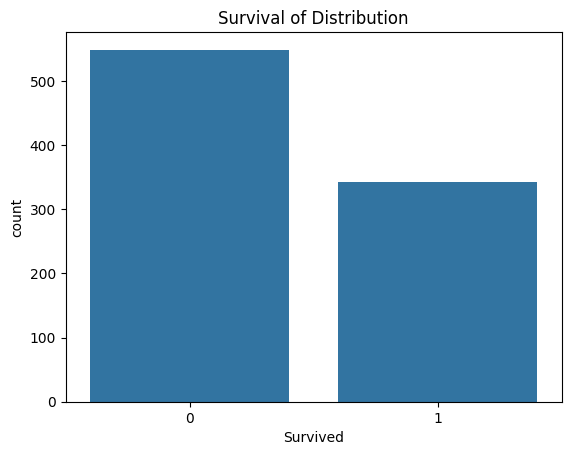

In [868]:
sns.countplot(x='Survived', data=df)
plt.title('Survival of Distribution')
plt.show()

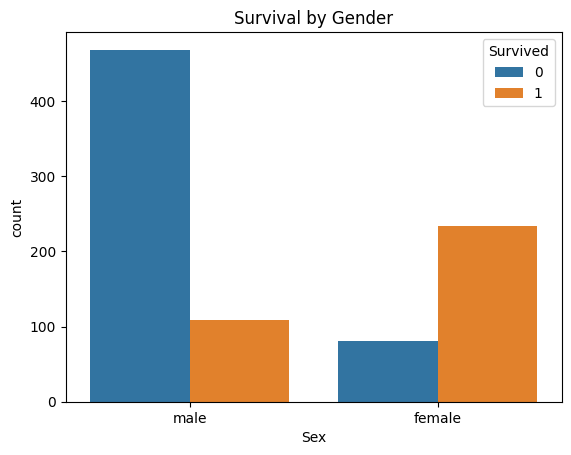

In [869]:
sns.countplot(x='Sex',hue='Survived', data=df)
plt.title('Survival by Gender')
plt.show()

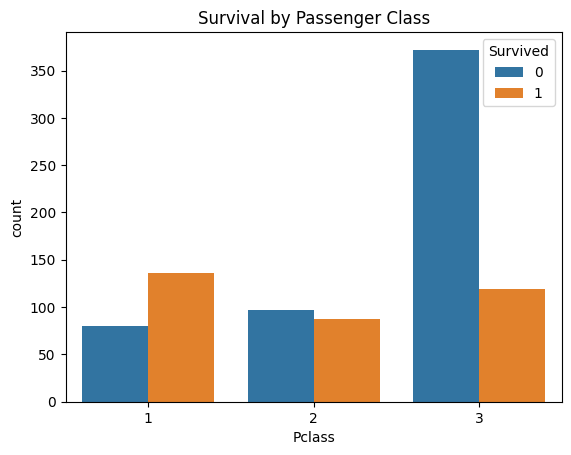

In [870]:
sns.countplot(x='Pclass',hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.show()

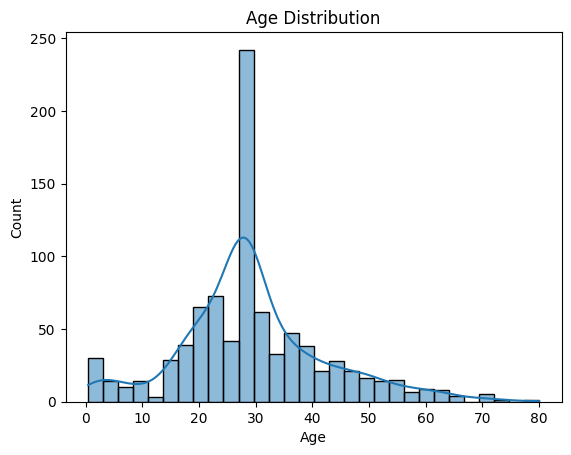

In [871]:
sns.histplot(df['Age'].dropna(), kde=True)
plt.title('Age Distribution')
plt.show()


# Select usefull columns

In [872]:
df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

In [873]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked
0,0,3,22.0,1,0,7.2500,S
1,1,1,38.0,1,0,71.2833,C
2,1,3,26.0,0,0,7.9250,S
3,1,1,35.0,1,0,53.1000,S
4,0,3,35.0,0,0,8.0500,S


#Convert into numbers

In [874]:
df = pd.get_dummies(df, columns=['Age','Embarked'], drop_first=True)

In [875]:
df.head()

,Survived,Pclass,SibSp,Parch,Fare,Age_0.67,Age_0.75,Age_0.83,Age_0.92,Age_1.0,...,Age_64.0,Age_65.0,Age_66.0,Age_70.0,Age_70.5,Age_71.0,Age_74.0,Age_80.0,Embarked_Q,Embarked_S
0,0,3,1,0,7.2500,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,1,1,1,0,71.2833,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,3,0,0,7.9250,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,1,1,1,0,53.1000,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,0,3,0,0,8.0500,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


#Seperate x and y

In [876]:
x = df.drop('Survived', axis=1)
y = df['Survived']

#Split the dataset

In [877]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train a Decision tree model

In [878]:
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

In [879]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

# Make predictions

In [880]:
y_pred = model.predict(X_test)

# Calculate accurancy

In [881]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100)

Accuracy: 0.6201117318435754
Accuracy Percentage: 62.01117318435754


# Generate classification report

In [882]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.74      0.70       110
           1       0.51      0.43      0.47        69

    accuracy                           0.62       179
   macro avg       0.59      0.59      0.59       179
weighted avg       0.61      0.62      0.61       179



# confusion matrix

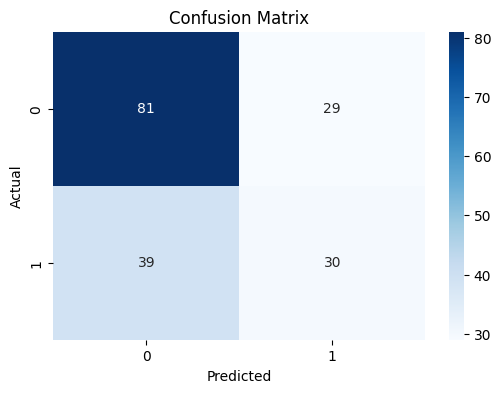

In [883]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Roc Courve

In [884]:
y_probability = model.predict_proba(X_test)[:, 1]

In [885]:
fpr, tpr, thresholds = roc_curve(y_test, y_probability)

In [886]:
auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.6597496706192358


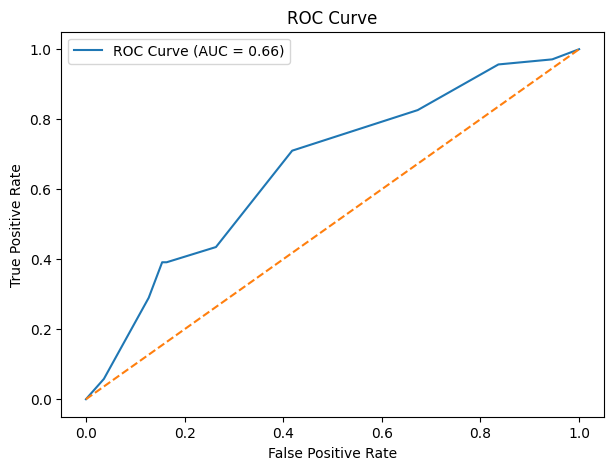

In [887]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f'ROC Curve (AUC = {auc:.2f})'
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Random Forest

In [888]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy Percentage:", rf_accuracy * 100)

Random Forest Accuracy: 0.6312849162011173
Random Forest Accuracy Percentage: 63.128491620111724


# Compare the model

In [889]:
print("Decision Tree Accuracy:", accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Decision Tree Accuracy: 0.6201117318435754
Random Forest Accuracy: 0.6312849162011173


In [890]:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy, rf_accuracy]
})

results

,Model,Accuracy
0,Decision Tree,0.620112
1,Random Forest,0.631285


# Feature impportance

In [891]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

importance

,0
Fare,0.361648
Pclass,0.085982
SibSp,0.062402
Parch,0.053532
Embarked_S,0.031358
...,...
Age_74.0,0.000172
Age_55.5,0.000123
Age_23.5,0.000000
Age_24.5,0.000000


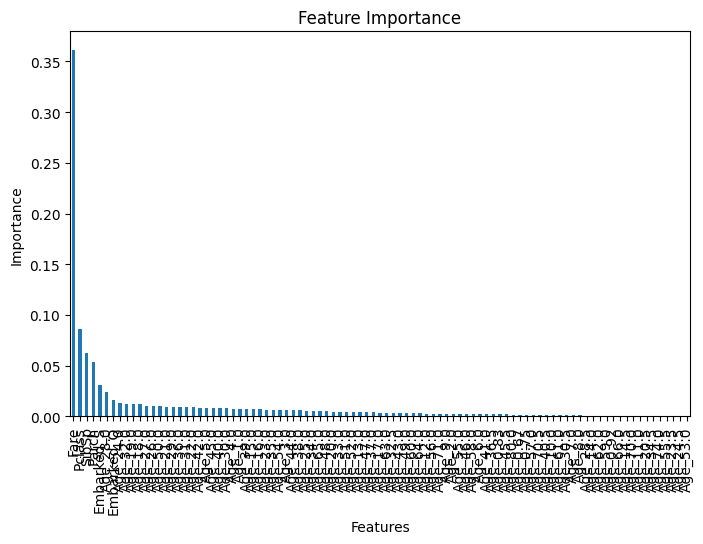

In [892]:
plt.figure(figsize=(8, 5))

importance.plot(kind='bar')

plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')

plt.show()